## Universidad Diego Portales
### Trabajo en Python
### Profesores: J. Rozas - M. Soto

TRABAJO DE PYTHON  EN COLLAB. FECHA DE ENTREGA 16-06-2025

INTEGRANTES: FRANCISCO PIÑERA / EZEQUIEL MORALES

### Contexto
#### Se analiza la base de datos simulada que contiene información sobre los profesionales del área de informática, las variables a analizar son: uso diario de internet, número de dispositivos, tiempo de sueño, productividad laboral autoevaluada, edad, género, y modalidad de trabajo (remoto, híbrido, presencial). Se busca analizar patrones de uso tecnológico y cómo estos se relacionan con la productividad.



# Fecha de entrega: 16 de junio hasta las 23:00 hrs

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm  # importacion de librerias. . .

# Creación de la DataFrame

np.random.seed(123) # semilla
n = 300

df = pd.DataFrame({
    'edad': np.random.randint(22, 60, n),
    'genero': np.random.choice(['Hombre', 'Mujer', 'Otro'], n),
    'horas_internet': np.round(np.random.normal(6, 2, n).clip(0, 12), 1),
    'dispositivos': np.random.randint(1, 6, n),
    'horas_sueno': np.round(np.random.normal(6.5, 1, n).clip(4, 10), 1),
    'productividad': np.round(np.random.normal(7, 1.5, n).clip(1, 10), 1),
    'modalidad': np.random.choice(['Remoto', 'Presencial', 'Híbrido'], n)
})

In [ ]:
# Analisis descriptivo general (300 filas, 7 variables)
df.describe()

,edad,horas_internet,dispositivos,horas_sueno,productividad
count,300.000000,300.000000,300.000000,300.00000,300.000000
mean,40.450000,5.899667,3.050000,6.44300,7.058333
std,11.279106,1.940046,1.395466,0.95026,1.331468
min,22.000000,0.200000,1.000000,4.00000,2.800000
25%,30.750000,4.600000,2.000000,5.80000,6.100000
50%,40.000000,5.900000,3.000000,6.50000,7.200000
75%,50.000000,7.200000,4.000000,7.10000,7.925000
max,59.000000,11.200000,5.000000,9.30000,10.000000


1.	¿Cuántas horas al día usan internet, en promedio, los profesionales de IT? ¿Este uso cambia según la edad, el género o el tipo de trabajo?

In [ ]:
# Analiis descriptivo del uso diario del internet.

("\n")
print("Uso promedio de internet en general")
print(df['horas_internet'].mean()) # La media arrojada para los 300 informaticos es 5.8997 horas
tempGeneral = df['horas_internet'].mean() # guarda el valor en una variable

print("-"*50)
print("Agrupacion por edad")
print("-"*50)
mean_internet_by_edad = df.groupby('edad')['horas_internet'].mean()
print(mean_internet_by_edad) # Media agrupada por edad
print("-"*50)

print("Agrupacion por genero")
print("-"*50)
print(df.groupby('genero')['horas_internet'].mean()) # Media agrupada por genero
print("-"*50)

print("Agrupacion por modalidad")
print("-"*50)
print(df.groupby('modalidad')['horas_internet'].mean()) # Media agrupada por modalidad
print("-"*50)

print('Analisis')
print('-'*50)
print('Analisis por modalidad')
print('-'*50)
tempHibrido = df.groupby('modalidad')['horas_internet'].mean().loc['Híbrido']
tempPresencial = df.groupby('modalidad')['horas_internet'].mean().loc['Presencial']
tempRemoto = df.groupby('modalidad')['horas_internet'].mean().loc['Remoto']

print('Para la modalidad Hibrida se tiene que la media es menor que la general:')
print(str(tempHibrido) + ' < ' + str(tempGeneral))
varH = df.groupby('modalidad')['horas_internet'].var().loc['Híbrido']
print('La varianza es: ' + str(varH))
stdH = df.groupby('modalidad')['horas_internet'].std().loc['Híbrido']
print('La desviacion estandar es: ' + str(stdH))
coefH = (stdH/tempHibrido)*100
print('El coeficiente de variacion es: ' + str(coefH)) # marca 29.48%
print('Conclusiones: En general la diferencia de medias es muy baja, teniendo una variacion de apenas unos cuantos decimales.')
print('Calculando la varianza, la desviacion estandar y el coeficiente de variabilidad se llega a que este ultimo de de un 29.48%')
print('Este valor se encuentra en los limites de lo que se considera homogeneo. Por lo que los datos recogidos se empiezan a alejar bastante de la media.')
print('Por ende, no se puede determinar con certeza si la modalidad hibrida influye un cambio real con respecto a la media general.')
print('')
print('Para la modalidad Presencial se tiene que la media es mayor que la general:')
print(str(tempPresencial) + ' > ' + str(tempGeneral))
varP = df.groupby('modalidad')['horas_internet'].var().loc['Presencial']
print('La varianza es: ' + str(varP))
stdP = df.groupby('modalidad')['horas_internet'].std().loc['Presencial']
print('La desviacion estandar es: ' + str(stdP))
coefP = (stdP/tempPresencial)*100
print('El coeficiente de variacion es: ' + str(coefP) +'%') # marca 31.04 %
print('Conclusiones: En general, a pesar de que la media presencial es mayor que la media general, la diferencia sigue siendo muy baja.')
print('Ademas, el coeficiente de variacion marco mas del 30%, dejando asi que los datos recogidos se alejan mucho de la media.')
print('Por ende, no se puede decir que la media obtenida sea realmente representativa. Por lo que, es probable que la media presencial pueda ser incluso menor que la media general')
print('')
print('Para la modalidad Remota se tiene que la media es mayor que la general:')
print(str(tempRemoto) + ' > ' + str(tempGeneral))
varR = df.groupby('modalidad')['horas_internet'].var().loc['Remoto']
print('La varianza es: ' + str(varR))
stdR = df.groupby('modalidad')['horas_internet'].std().loc['Remoto']
print('La desviacion estandar es: ' + str(stdR))
coefR = (stdR/tempRemoto)*100
print('El coeficiente de variacion es: ' + str(coefR) +'%') # marca 36.99%
print('Para la media remota se tiene que es mayor que la media general con una variacion muy baja. Y ademas teniendo un coeficiente de variabilidad')
print('superior al 30%, por lo que no se puede afirmar que la media obtenida sea realmente representativa, dejando asi una posibilidad que esta media')
print('sea incluso menor que la media general si se da el caso')
print('')
print('Conclusion final: Debido a la poca heterogeniedad presente entre la media general y las modalidades. No se puede afirmar que la modalidad de trabajo')
print('afecte al promedio de uso de internet de los profesionales de IT de manera significativa.')


print('-'*50)
print('Analisis por genero')
print('-'*50)
tempHombre = df.groupby('genero')['horas_internet'].mean().loc['Hombre']
tempMujer = df.groupby('genero')['horas_internet'].mean().loc['Mujer']
tempOtro = df.groupby('genero')['horas_internet'].mean().loc['Otro']

print('Para el genero Hombre se tiene que la media es menor que la general:')
print(str(tempHombre) + ' < ' + str(tempGeneral))
varH = df.groupby('genero')['horas_internet'].var().loc['Hombre']
print('La varianza es: ' + str(varH))
stdH = df.groupby('genero')['horas_internet'].std().loc['Hombre']
print('La desviacion estandar es: ' + str(stdH))
coefH = (stdH/tempHombre)*100
print('El coeficiente de variacion es: ' + str(coefH))
print('Conclusiones: Ahora la diferencia de medias es mayor que en la modalidad vs general. por lo que se puede decir que el genero influye mas que la modalidad.')
print('Calculando la varianza, la desviacion estandar y el coeficiente de variabilidad se llega a que este ultimo de de un ' + str(coefH) + '%')
print('Este valor es mas del 30% por lo que se puede decir que es un resultado hetereogeneo y por ende los valores se alejan bastante de la media.')
print('Por ende, es probable que la media "mas real" peuda ser diferente pero dado el nivel de diferencia, es mas dificil que este valor final pueda llegar a ser mayor que la general')
print('')
print('Para el genero Mujer se tiene que la media es menor que la general:')
print(str(tempMujer) + ' < ' + str(tempGeneral))
varM = df.groupby('genero')['horas_internet'].var().loc['Mujer']
print('La varianza es: ' + str(varM))
stdM = df.groupby('genero')['horas_internet'].std().loc['Mujer']
print('La desviacion estandar es: ' + str(stdM))
coefM = (stdM/tempMujer)*100
print('El coeficiente de variacion es: ' + str(coefM) +'%')
print('Conclusiones: En general, a pesar de que la media de Mujer es menor que la media general, la diferencia es bastante baja.')
print('Ademas, el coeficiente de variacion marco mas del 30%, dejando asi que los datos recogidos se alejan mucho de la media. Por lo tanto,')
print('no se puede decir que la media obtenida sea realmente representativa. Por lo que, es probable que la media de Mujer pueda ser incluso menor o mayor que la general.')
print('')
print('Para el genero Otro se tiene que la media es mayor que la general:')
print(str(tempOtro) + ' > ' + str(tempGeneral))
varO = df.groupby('genero')['horas_internet'].var().loc['Otro']
print('La varianza es: ' + str(varO))
stdO = df.groupby('genero')['horas_internet'].std().loc['Otro']
print('La desviacion estandar es: ' + str(stdO))
coefO = (stdO/tempOtro)*100
print('El coeficiente de variacion es: ' + str(coefO) +'%')
print('Para la media de Otro se tiene que es considerablemente mayor a la media general con una variacion bastante mas alta. Ademas, se tiene un coeficiente de variabilidad')
print('superior al 30%, por lo que si bien es probable que la media mas realista sea diferente, aqui es mucho menos probable que el valor final sea menor a la media general.')
print('')
print('Conclusion final: Hay mayor heterogeniedad presente entre la media general y los generos. Teniendo como resultado que el genero "otro" y el genero "hombre" afecta mas en el uso de internet a diferencia del caso de las mujeres.')

print('-'*50)
print('Analisis por edad')
print('-'*50)
edades_menor_media = mean_internet_by_edad[mean_internet_by_edad < tempGeneral].index
edades_mayor_igual_media = mean_internet_by_edad[mean_internet_by_edad >= tempGeneral].index

print("\nEdades con media de horas de internet menor que la media general:")
print(edades_menor_media.tolist())

print("\nEdades con media de horas de internet mayor o igual que la media general:")
print(edades_mayor_igual_media.tolist())
print('')
print('Simplemente con ver la comparacion se puede apreciar que no hay ningun distintivo que permita identificar si la edad afecta o no la media de interntet')
print('Puesto que hay igual rango de edades para ambos casos de edades menores a la media y mayores a la media.')
print('Es por eso que se puede concluir que la edad no afecta la media de horas de internet entre los profesionales de IT')



Uso promedio de internet en general
5.899666666666667
--------------------------------------------------
Agrupacion por edad
--------------------------------------------------
edad
22    5.220000
23    5.045455
24    7.050000
25    6.406667
26    5.720000
27    4.771429
28    6.600000
29    5.266667
30    6.500000
31    6.250000
32    5.357143
33    6.216667
34    6.814286
35    5.857143
36    6.207692
37    8.025000
38    5.012500
39    4.645455
40    5.014286
41    5.845455
42    5.740000
43    5.857143
44    6.520000
45    6.090909
46    7.325000
47    6.036364
48    5.742857
49    5.737500
50    6.488889
51    6.480000
52    5.610000
54    5.190909
55    5.833333
56    5.337500
57    6.108333
58    6.214286
59    6.133333
Name: horas_internet, dtype: float64
--------------------------------------------------
Agrupacion por genero
--------------------------------------------------
genero
Hombre    5.766667
Mujer     5.849515
Otro      6.096842
Name: horas_internet, dtype: float64
--

2.	¿Cuál es la modalidad de trabajo en la que los trabajadores reportan mayor productividad, y cuál tiene menor?

In [ ]:
print(df.groupby('modalidad')['productividad'].mean()) # Media de productividad por cada modalidad de trabajo
print('-'*50)
print('Para la modalidad hbrida, se tiene que la media de productividad es de 7.071')
print('Para la modalidad presencial, se tiene que la media de productividad es de 6.957')
print('Para la modalidad remota, se tiene que la media de productividad es de 7.1414')
print('-'*50)
print('En general, el rango de medias esta entre un 0.2 y 0.3 aproximadamente. Es por ello que en general ninguna modalidad tiene un rendimiento aplastante con respecto a la otra.')
tempH = df.groupby('modalidad')['productividad'].mean().loc['Híbrido']
tempP = df.groupby('modalidad')['productividad'].mean().loc['Presencial']
tempR = df.groupby('modalidad')['productividad'].mean().loc['Remoto']                       # Calculos necesarios para obtener el coeficiente de variabilidad.
stdh = df.groupby('modalidad')['productividad'].std().loc['Híbrido']
stdp = df.groupby('modalidad')['productividad'].std().loc['Presencial']
stdr = df.groupby('modalidad')['productividad'].std().loc['Remoto']
coefH = (stdh/tempH)*100
coefP = (stdp/tempP)*100
coefR = (stdr/tempR)*100
print('El coeficiente e variabilidad para la modalidad Hibrida es: ' + str(coefH) +'%')
print('El coeficiente e variabilidad para la modalidad Presencial es: ' + str(coefP) +'%')
print('El coeficiente e variabilidad para la modalidad Remota es: ' + str(coefR) +'%')
print('')
print('Analizando los coeficientes de variabilidad se puede observar que son bastante buenos')
print('Por lo que, en resumen la modalidad remota es la que presenta mayor media de productividad mientras que la modalidad presencial es la que')
print('presenta menor media de productividad')
print('Debido al contexto de la situacion, se puede analizar que los trabajadores que permanecen trabajando desde sus casas presentan mayor nivel de')
print('productividad, los que trabajan de manera hibrida permanecen entre medio y los que permanecen en presencial presentan menor productividad.')
print('Por lo que, es valido concretar que trabajar desde casa tiene mayor beneficio para los trabajadores que trabajar presencial.')
print('-'*50)
var = df.groupby('modalidad')['productividad'].var().loc['Presencial'] # varianza para las 3 modalidades
print(var)
var2 = df.groupby('modalidad')['productividad'].var().loc['Remoto']
print(var2)
var3 = df.groupby('modalidad')['productividad'].var().loc['Híbrido']
print(var3)
print(df.groupby('modalidad')['productividad'].describe())
print('-'*50)
print('Debido a que la varianza para las 3 modalidades es similiar, y tambien la cantidad de datos que hay por modalidad tambien lo es. Se podria decir que las medias son lo suficientemente representativas como para afirmar lo de arriba')




modalidad
Híbrido       7.071264
Presencial    6.956863
Remoto        7.141441
Name: productividad, dtype: float64
--------------------------------------------------
Para la modalidad hbrida, se tiene que la media de productividad es de 7.071
Para la modalidad presencial, se tiene que la media de productividad es de 6.957
Para la modalidad remota, se tiene que la media de productividad es de 7.1414
--------------------------------------------------
En general, el rango de medias esta entre un 0.2 y 0.3 aproximadamente. Es por ello que en general ninguna modalidad tiene un rendimiento aplastante con respecto a la otra.
El coeficiente e variabilidad para la modalidad Hibrida es: 18.519001071736014%
El coeficiente e variabilidad para la modalidad Presencial es: 19.868770672202228%
El coeficiente e variabilidad para la modalidad Remota es: 18.295879015596537%
Por lo que, en resumen la modalidad remota es la que presenta mayor media de productividad mientras que la modalidad presencial es l

3.	¿Los hombres, mujeres y otros géneros usan internet y dispositivos de manera diferente? ¿Quiénes duermen más o son más productivos?, use estadisticos descriptivos y gráficos

descriptivo por internet
        count  mean  std  min  25%  50%  75%   max
genero                                            
Hombre  102.0   6.0  2.0  0.0  5.0  6.0  7.0  11.0
Mujer   103.0   6.0  2.0  0.0  4.0  6.0  7.0  11.0
Otro     95.0   6.0  2.0  1.0  5.0  6.0  8.0  10.0
--------------------------------------------------
descriptivo por dispositivos
        count  mean  std  min  25%  50%  75%  max
genero                                           
Hombre  102.0   3.0  1.0  1.0  2.0  3.0  4.0  5.0
Mujer   103.0   3.0  1.0  1.0  2.0  3.0  4.0  5.0
Otro     95.0   3.0  1.0  1.0  2.0  3.0  4.0  5.0
--------------------------------------------------
descriptivo por sueño
        count  mean  std  min  25%  50%  75%  max
genero                                           
Hombre  102.0   6.0  1.0  4.0  6.0  6.0  7.0  8.0
Mujer   103.0   7.0  1.0  4.0  6.0  7.0  7.0  9.0
Otro     95.0   6.0  1.0  4.0  6.0  6.0  7.0  9.0
--------------------------------------------------
descriptivo por 

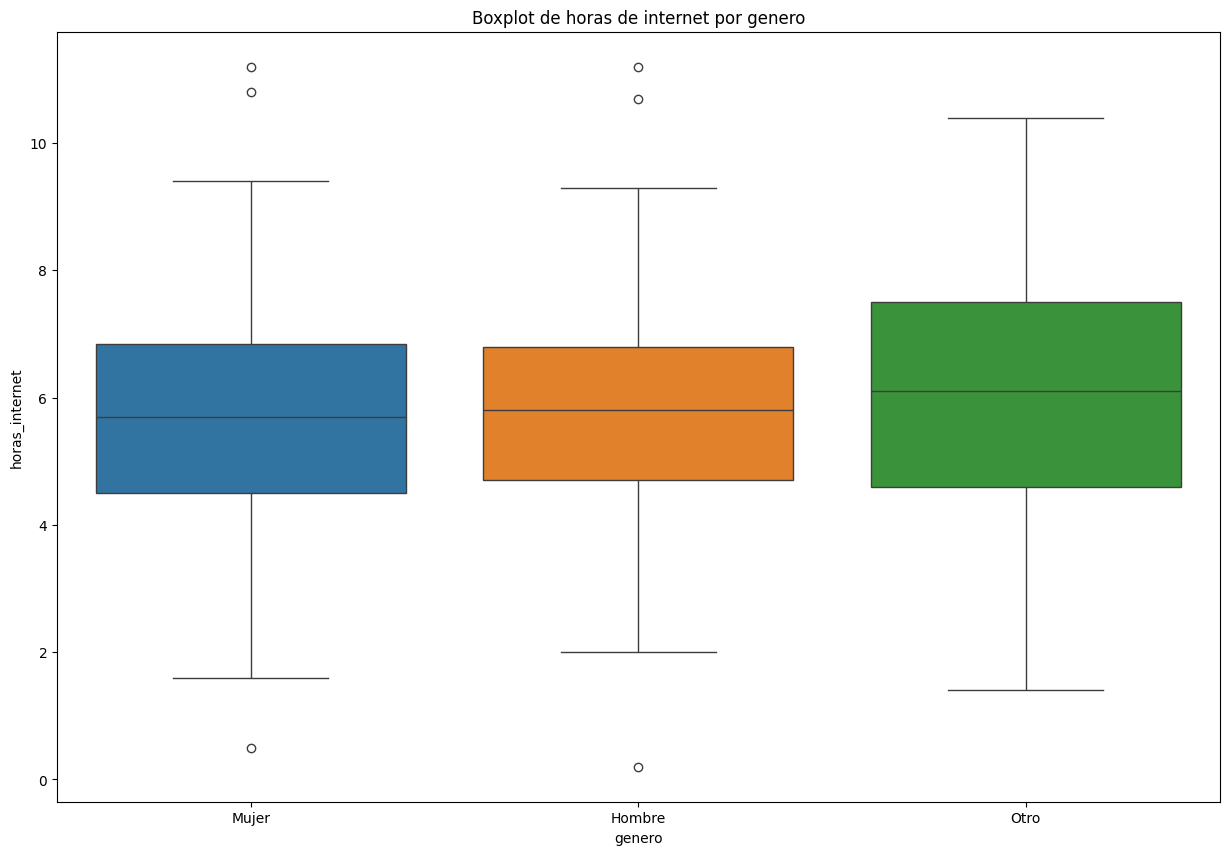

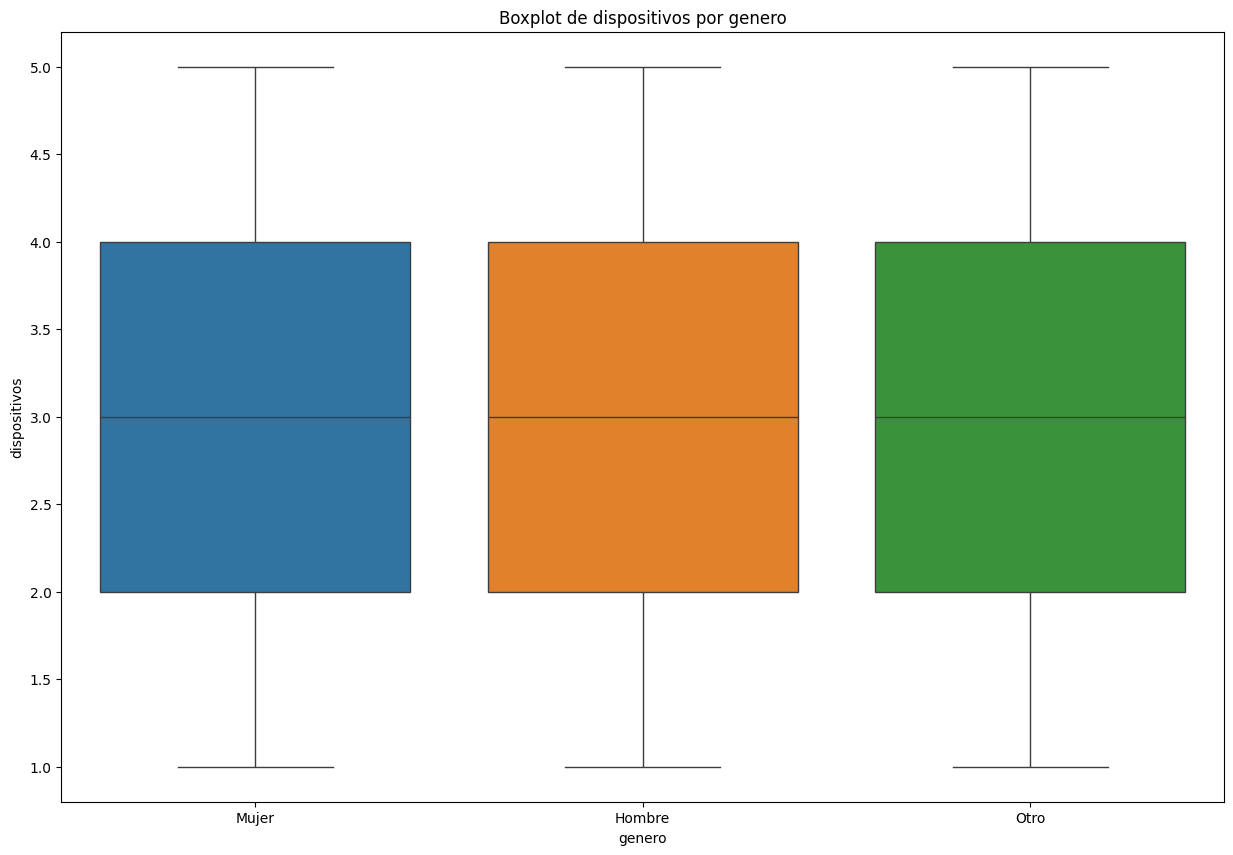

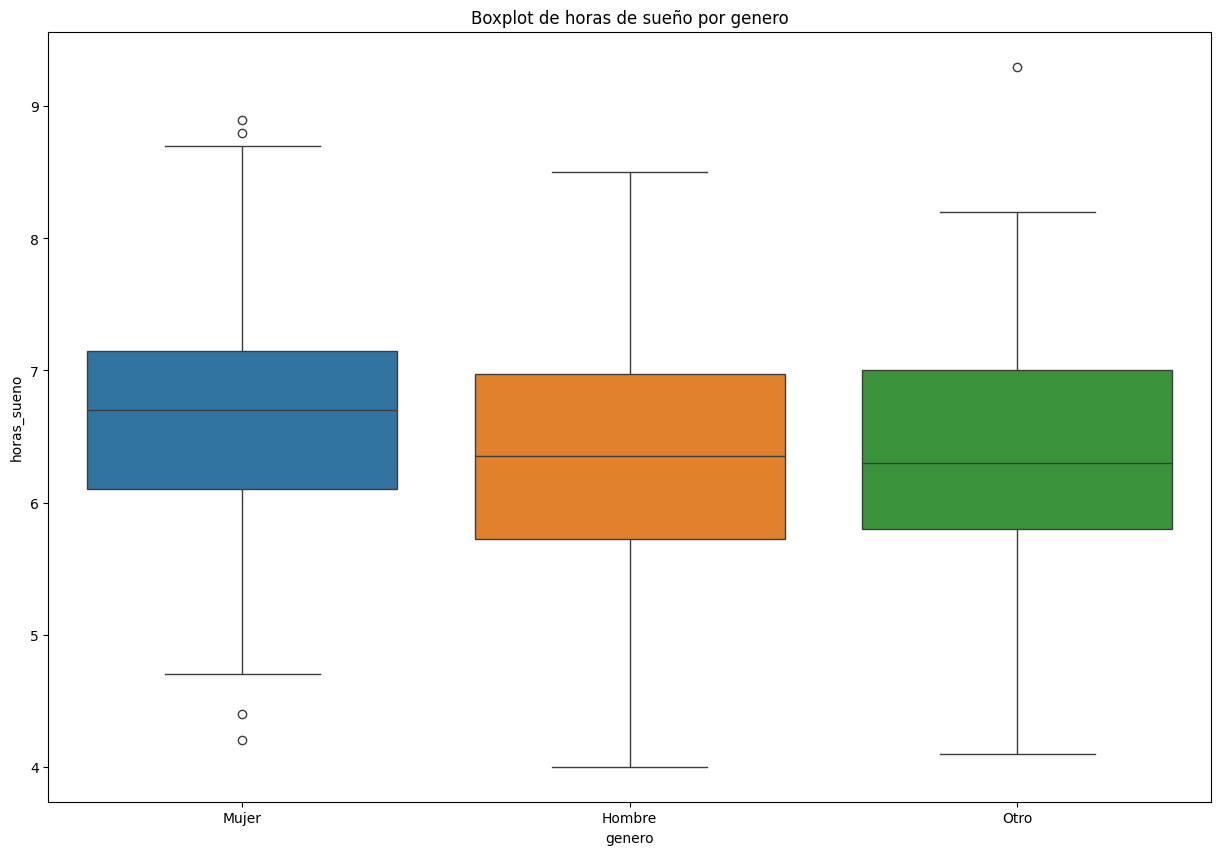

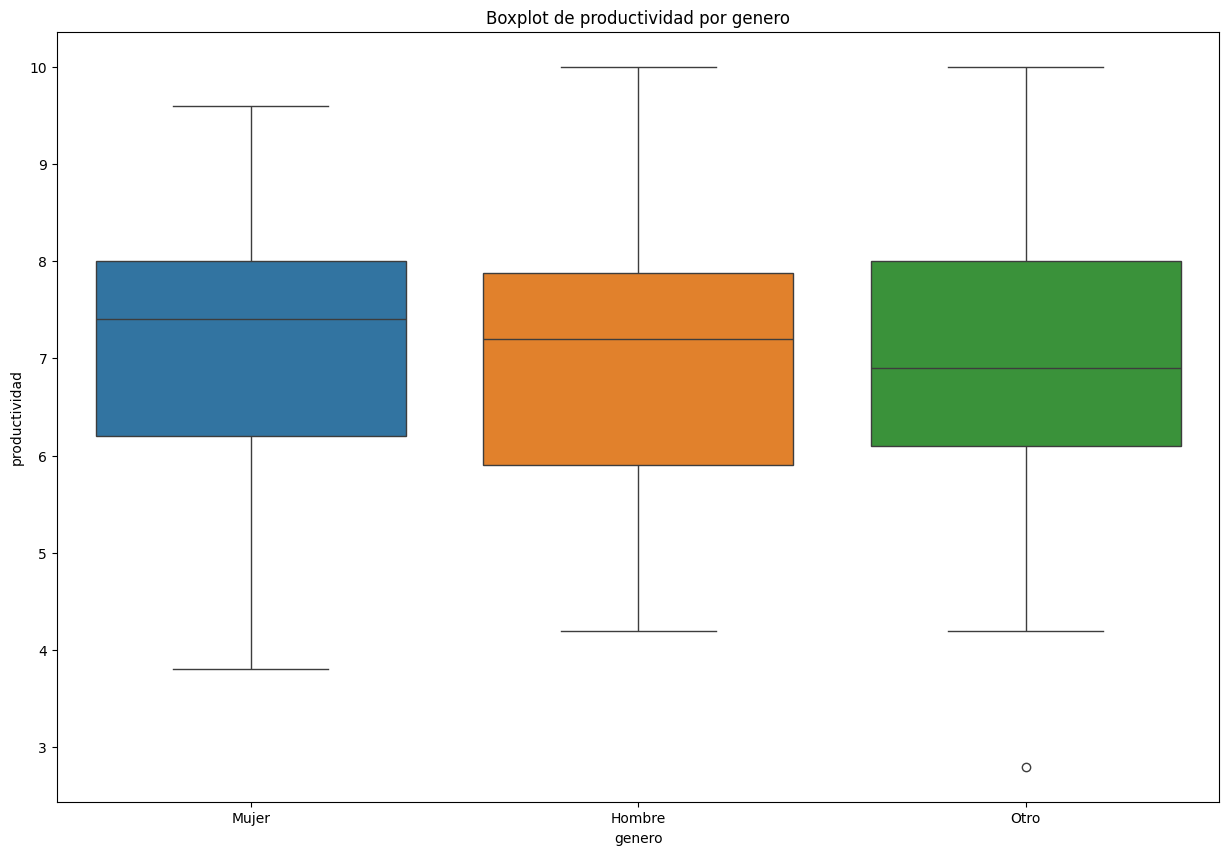

--------------------------------------------------
Analisis por internet:
Observando el bocplot, El genero "otro" es el que presenta mayor rango de valores atipicos, y a su vez es el que tambien alcanza los valores mas altos en el 3er cuartil
Por lo que se podria decir que el genero "otro", utiliza internet con mas frecuencia que los otros dos generos.
Por otro lado, los hombres tienen valores mas centrados hacia la mediana por lo que presentan menor rango de valores atipicos que los otros dos generos.
Por lo que, la media de uso de internet en los hombres esta mejor definida entre 4.5 y 6.5 horas.
Las nujeres tienden a utilizar menos el internet que los hombres pero de igual forma tienen un rango mas elevado de valores atipicos.
En resumen, el genero "otro" tiene mayor variacion en el uso de internet mientras que los hombres tienen un rango de valores mejor definido.
--------------------------------------------------
Analisis por dispositivos
Sorprendentemente, se puede concluir insta

In [ ]:
print('descriptivo por internet')
print(df.groupby('genero')['horas_internet'].describe().round()) # descriptivo por internet
print('-'*50)
print('descriptivo por dispositivos')
print(df.groupby('genero')['dispositivos'].describe().round()) # descriptivo por dispositivos
print('-'*50)
print('descriptivo por sueño')
print(df.groupby('genero')['horas_sueno'].describe().round()) # descriptivo por sueño
print('-'*50)
print('descriptivo por productividad')
print(df.groupby('genero')['productividad'].describe().round()) # descriptivo por productividad
print('-'*50)

plt.figure(figsize=(15, 10))
sns.boxplot(x="genero", y="horas_internet", hue="genero", data=df)
plt.title("Boxplot de horas de internet por genero")
plt.show()
print(' ')
plt.figure(figsize=(15, 10))
sns.boxplot(x="genero", y="dispositivos", hue="genero", data=df)
plt.title("Boxplot de dispositivos por genero")
plt.show()
print(' ')
plt.figure(figsize=(15, 10))
sns.boxplot(x="genero", y="horas_sueno", hue="genero", data=df)
plt.title("Boxplot de horas de sueño por genero")
plt.show()
print(' ')
plt.figure(figsize=(15, 10))
sns.boxplot(x="genero", y="productividad", hue="genero", data=df)
plt.title("Boxplot de productividad por genero")
plt.show()

# Analisis abajo

print('-'*50)
print('Analisis por internet:')
print('Observando el bocplot, El genero "otro" es el que presenta mayor rango de valores atipicos, y a su vez es el que tambien alcanza los valores mas altos en el 3er cuartil')
print('Por lo que se podria decir que el genero "otro", utiliza internet con mas frecuencia que los otros dos generos.')
print('Por otro lado, los hombres tienen valores mas centrados hacia la mediana por lo que presentan menor rango de valores atipicos que los otros dos generos.')
print('Por lo que, la media de uso de internet en los hombres esta mejor definida entre 4.5 y 6.5 horas.')
print('Las mujeres tienden a utilizar menos el internet que los hombres pero de igual forma tienen un rango mas elevado de valores atipicos.')
print('En resumen, el genero "otro" tiene mayor variacion en el uso de internet mientras que los hombres tienen un rango de valores mejor definido.')
print('-'*50)
print('Analisis por dispositivos')
print('Sorprendentemente, se puede concluir instantaneamente que el genero no influye en el numero de dispositivos ya que para los 3 generos el resultado es exactamente el mismo')
print('-'*50)
print('Analisis por sueño')
print('Observando el bocplot, las mujeres presentan una mediana de sueño mas alta, pero a su vez son las que mayor cantidad de valores atipicos posee.')
print('por otro lado los hombres son los que presentan la minima mas baja dando lugar a que es mas probable que un hombre duerma muy poco o duerma moderadamente.')
print('Mientras que el genero "otro" tiene valores mas definidos entre las 6 y 7 horas.')
print('-'*50)
print('Analisis por productividad')
print('El genero "hombre" y "otro" tienen valores muy similares de productividad, aunque en profundiad los hombres tienen una mediana de valores mas cercana al 75% mientras que el otro genero tienen la mediana mas cercana al 25%.')
print('Por otro lado, las mujeres presentan un rango mas desplazado hacia abajo por lo que presentan una maxima menor y la menor mas baja tambien.')
print('Conclusion: las mujeres tienen a percibir menor productividad que los otros 2 generos.')


4.	¿Existe alguna relación entre la cantidad de dispositivos que se usan y la productividad en el trabajo?, use matriz de correlación, mapa de calor. Interprete

               dispositivos  productividad
dispositivos       1.000000       0.061725
productividad      0.061725       1.000000
--------------------------------------------------


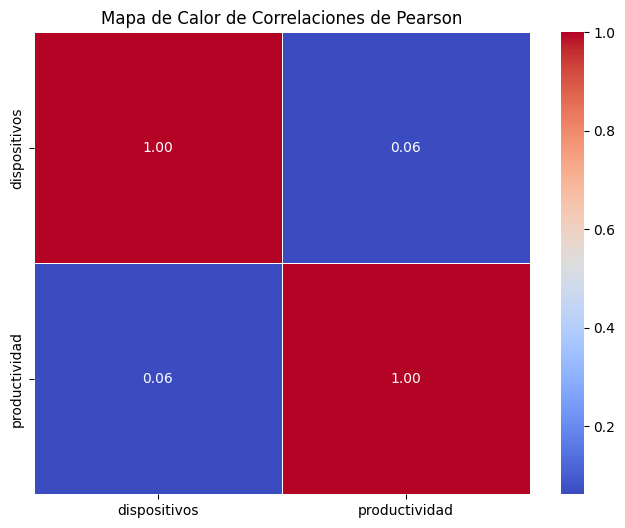

 
Solamente observando el mapa se puede observar que los valores que nos interesan son aquellos que logran una interseccion entre 2 variables diferentes.
Sin importar el orden, la relacion entre numero de dispositivos y productividad presentan el mismo valor, el cual es POSITIVO.
El valor de la relacion es de 0.06. Este valor nos indica que esta extremadamente cerca del valor 0.
Cuando el valor de la relacion se acerca mucho a 0 se concluye que la relacion es pesima o directamente no existe relacion entre las variables.
Conclusion: La relacion es casi 0, por lo que se concluye que el numero de dispositivos no afecta el nivel de productividad.


In [ ]:
columnas_select = df[['dispositivos', 'productividad']]
matrixS = columnas_select.corr(method='spearman') # Aplicacion de la matriz de correlacion de spearman
print(matrixS)
print('-'*50)

plt.figure(figsize=(8, 6))
sns.heatmap(matrixS, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones de Pearson")
plt.show()

# Analisis aqui abajo
print(' ')
print('Solamente observando el mapa se puede observar que los valores que nos interesan son aquellos que logran una interseccion entre 2 variables diferentes.')
print('Sin importar el orden, la relacion entre numero de dispositivos y productividad presentan el mismo valor, el cual es POSITIVO.')
print('El valor de la relacion es de 0.06. Este valor nos indica que esta extremadamente cerca del valor 0.')
print('Cuando el valor de la relacion se acerca mucho a 0 se concluye que la relacion es pesima o directamente no existe relacion entre las variables.')
print('Conclusion: La relacion es casi 0, por lo que se concluye que el numero de dispositivos no afecta el nivel de productividad.')

5.	Realice un análisis de regresión lineal simple que permita explicar la variable dependiente productividad en función de la variable independiente horas_internet

In [ ]:
# import necesario para mostrar el grafico (2 Estadistica descriptiva UDP (1).ipynb)
import statsmodels.formula.api as smf

modelo = smf.ols("productividad ~ horas_internet", data=df).fit()
print("Resumen del modelo de regresión lineal:")
print('-'*50)
print(modelo.summary())
print('-'*50)
# Añadir analisis
print('Para poder analizar el modelo de regresión lineal con los siguientes datos, antes se debe conocer que significa cada uno de estos datos entregados y comparados en relación a la variable dependiente de productividad en función a la variable independiente horas_internet')
print('Se tiene')
print('-'*50)
print('Modelo de regresión lineal: y = a + bx')
print('y: productividad')
print('x: horas_internet')
print('a: intercepto de la recta o respuesta base')
print('b: gradiente de la recta o razón de cambio para cada unidad que aumente x (horas_internet)')
print('-'*50)
print('Por lo que teniendo claros estos datos se puede proceder a crear nuestra función:')
print('y = 7.5676 - 0.0863x')
print('Lo que nos indica que al tener una pendiente o razon de cambio negativa (-0.0863) se puede interpretar que a mayor horas de internet menor productividad se tiene')
print('De igual forma se tiene la respuesta base con un valor de 7.5676 donde si las horas de internet son 0 la productividad esperada es de aproximadamente 7.5676')
print('-'*50)


Resumen del modelo de regresión lineal:
--------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:          productividad   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     4.790
Date:                Mon, 16 Jun 2025   Prob (F-statistic):             0.0294
Time:                        23:21:41   Log-Likelihood:                -508.67
No. Observations:                 300   AIC:                             1021.
Df Residuals:                     298   BIC:                             1029.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

6.	Realice gráficos de dispersión entre las siguientes variables: productividad (y) y horas_sueño (x); productividad (y) y horas_internet (x); productividad (y) y edad (x). Interprete cada relación


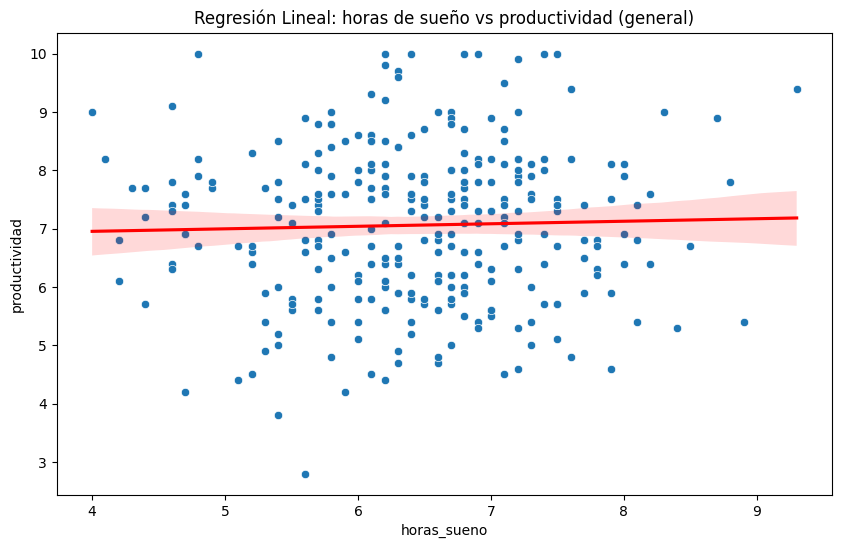

--------------------------------------------------
Coeficiente de correlación de Pearson entre productividad y horas_sueno: 0.03
--------------------------------------------------
Tras observar el gráfico con una dispersión considerable y analizar el coeficiente de correlación de pearson: 0.03 para la comparación de horas de sueño vs productividad, al ser un valor cercano a 0 y lejano a 1 indica una relación casi nula.
Por lo que comparar estas variables es irrelevante para un estudio de regresión lineal.
--------------------------------------------------


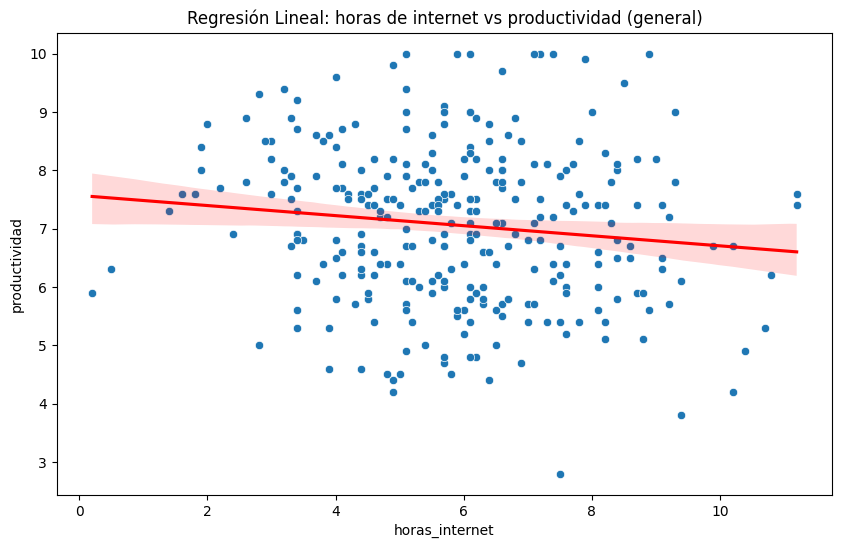

--------------------------------------------------
Coeficiente de correlación de Pearson entre productividad y horas_internet: -0.13
--------------------------------------------------
Tras observar el gráfico con una dispersión considerable y analizar el coeficiente de correlación de pearson: -0.13 para la comparación de horas de internet vs productividad, al ser un valor lejano a -1 indica una relación casi nula.
Por lo que comparar estas variables es irrelevante para un estudio de regresión lineal.
--------------------------------------------------


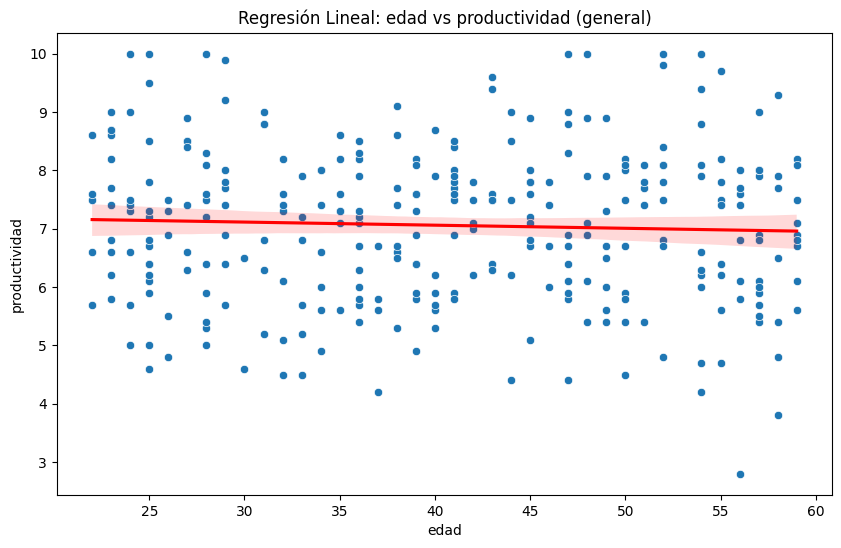

--------------------------------------------------
Coeficiente de correlación de Pearson entre productividad y edad: -0.05
--------------------------------------------------
Tras observar el gráfico con una dispersión considerable y analizar el coeficiente de correlación de pearson: -0.05 para la comparación de horas de internet vs productividad, al ser un valor cercano a 0 y lejano a -1 indica una relación casi nula.
Por lo que comparar estas variables es irrelevante para un estudio de regresión lineal.


In [10]:
correlation_sueno_productividad = df['productividad'].corr(df['horas_sueno'], method='pearson')
correlation_internet_productividad = df['productividad'].corr(df['horas_internet'], method='pearson')
correlation_edad_productividad = df['productividad'].corr(df['edad'], method='pearson')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="horas_sueno", y="productividad")
sns.regplot(data=df, x="horas_sueno", y="productividad", scatter=False, color="red", label="Regresión general")
plt.title("Regresión Lineal: horas de sueño vs productividad (general)")
plt.show() # Regresion lineal de productividad vs horas de sueño
print('-'*50)
print(f"Coeficiente de correlación de Pearson entre productividad y horas_sueno: {correlation_sueno_productividad:.2f}")
print('-'*50)

print('Tras observar el gráfico con una dispersión considerable y analizar el coeficiente de correlación de pearson: 0.03 para la comparación de horas de sueño vs productividad, al ser un valor cercano a 0 y lejano a 1 indica una relación casi nula.')
print('Por lo que comparar estas variables es irrelevante para un estudio de regresión lineal.')

print('-'*50)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="horas_internet", y="productividad")
sns.regplot(data=df, x="horas_internet", y="productividad", scatter=False, color="red", label="Regresión general")
plt.title("Regresión Lineal: horas de internet vs productividad (general)")
plt.show() # Regresion lineal de productividad vs horas_internet
print('-'*50)
print(f"Coeficiente de correlación de Pearson entre productividad y horas_internet: {correlation_internet_productividad:.2f}")
print('-'*50)

print('Tras observar el gráfico con una dispersión considerable y analizar el coeficiente de correlación de pearson: -0.13 para la comparación de horas de internet vs productividad, al ser un valor lejano a -1 indica una relación casi nula.')
print('Por lo que comparar estas variables es irrelevante para un estudio de regresión lineal.')

print('-'*50)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="edad", y="productividad")
sns.regplot(data=df, x="edad", y="productividad", scatter=False, color="red", label="Regresión general")
plt.title("Regresión Lineal: edad vs productividad (general)")
plt.show() # Regresion lineal de productividad vs la edad
print('-'*50)
print(f"Coeficiente de correlación de Pearson entre productividad y edad: {correlation_edad_productividad:.2f}")
print('-'*50)

print('Tras observar el gráfico con una dispersión considerable y analizar el coeficiente de correlación de pearson: -0.05 para la comparación de horas de internet vs productividad, al ser un valor cercano a 0 y lejano a -1 indica una relación casi nula.')
print('Por lo que comparar estas variables es irrelevante para un estudio de regresión lineal.')


In [ ]:
import pandas as pd

# Assuming the data is in a CSV file named 'data.csv' in the '/tmp/' directory.
# Replace with the actual path if different.
try:
    df = pd.read_csv('/tmp/data.csv')
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please provide the correct path to the data file.")
    # You might want to load data from another source or handle the error differently
    # For example, if the data is generated in another cell, ensure that cell is run first.